In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_palette("husl")

# Click-Through Rate Prediction Analysis

This notebook performs an exploratory data analysis on the click-through rate (CTR) dataset, visualizing various aspects of user behavior and click patterns using complex charts and graphs.

In [13]:
# Load the dataset
try:
    df = pd.read_parquet('/root/my_proje1/cleaned_data.parquet')
    print("Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
except Exception as e:
    print(f"Error loading data: {e}")
    # Alternative: if data is in current directory
    try:
        df = pd.read_csv('local_train', sep='\t', header=None, 
                        names=['click', 'user', 'movie_id', 'category', 'hist_movies', 'hist_categories'])
        print("Loaded local_train data instead")
    except:
        print("Could not load data")

Data loaded successfully!
Shape: (484516, 39)
Columns: ['_c0', 'user_id_masked', 'user_gender', 'user_visit_city_id', 'user_avg_price_hist', 'is_vip', 'user_click_rate_30d', 'user_order_cnt_30d', 'user_trade_amt_30d', 'shop_id_masked', 'item_id_masked', 'item_city_id', 'item_district_id', 'item_aoi_id', 'item_geohash6', 'item_geohash12', 'brand_id', 'item_cat1_id', 'item_std_dish_cat_id', 'item_sales_rank_7d', 'item_sales_rank_30d', 'item_sales_rank_90d', 'click_hist_shop_id_masked', 'click_hist_item_id_masked', 'click_hist_item_cat1_id', 'click_hist_item_std_dish_id', 'click_hist_brand_id', 'click_hist_item_price', 'click_hist_item_aoi_id', 'click_hist_item_geohash6', 'click_hist_time_diff_s', 'click_hist_click_hour', 'click_hist_click_time_slot', 'click_hist_click_day_of_week', 'request_timestamp', 'current_hour', 'current_time_slot', 'current_day_of_week', 'user_geohash12']


In [14]:
# Data exploration
if 'df' in locals():
    print("First 5 rows:")
    display(df.head())
    print("\nData info:")
    display(df.info())
    print("\nDescriptive statistics:")
    display(df.describe())
    
    # Check for missing values
    print("\nMissing values:")
    display(df.isnull().sum())

First 5 rows:


,_c0,user_id_masked,user_gender,user_visit_city_id,user_avg_price_hist,is_vip,user_click_rate_30d,user_order_cnt_30d,user_trade_amt_30d,shop_id_masked,...,click_hist_item_geohash6,click_hist_time_diff_s,click_hist_click_hour,click_hist_click_time_slot,click_hist_click_day_of_week,request_timestamp,current_hour,current_time_slot,current_day_of_week,user_geohash12
0,0,601b640aa477c38bcdcfabc4108a6c3264123e2774cadf...,2,14,90.387779,1,139,45,4067.449951,a351d550ead292285c2b62b056ad68472fa3bcd4c0f0e1...,...,wm6n1r;wm6n1r;wm6n1r;wm6n1r;wm6n1r;wm6n1r;wm6n...,96;117;130;139;174;184;211;235;337;359;5487;89...,21;21;21;21;21;21;21;21;21;21;20;19;15;22;22;2...,night;night;night;night;night;night;night;nigh...,5;5;5;5;5;5;5;5;5;5;5;5;5;4;4;4;4;4;4;4;4;4;4;...,2022-04-02 13:50:48,21,night,5,wm6n1rtw02x0
1,1,025d99e847c43fd6a87a07be3bdd1af32e2f03906d2eda...,unknown,6,53.459999,0,12,3,160.380005,817c975e556cb5e9ed00dfbd22168ef6cefae8928055bf...,...,wtsmyg;wtsmyg;wtsmyg;wtsmyg;wtsmyg;wtsmyg;wtsm...,22;23;66;236;278;302;82967;82975;113051;113063...,18;18;18;18;18;18;19;19;11;11;11;17;17;17;17;1...,dinner;dinner;dinner;dinner;dinner;dinner;dinn...,5;5;5;5;5;5;4;4;4;4;4;3;3;3;3;2;2;2;2,2022-04-02 10:37:21,18,dinner,5,wtsmyg1t9h36
2,0,6c1e11cb312e8f5b44fe1849d6ff94a75fdb53ab9a72a3...,2,13,52.799999,0,9,1,52.799999,1664fe360da90efc9ac945d1e2bcbbd6ece01a048cdb1d...,...,wskh68;wskh68;wskh68;wzc1m9;wzc1m9;wzc1m9;wzc1...,90869;90909;91099;2464566;2464578;2464599;2464...,21;21;21;9;9;9;9;17;17;17;17;17;16;16;16;16;16,night;night;night;breakfast;breakfast;breakfas...,4;4;4;5;5;5;5;2;2;2;2;2;2;2;2;2;2,2022-04-02 14:29:29,22,night,5,wzc1m9mczned
3,0,17fdc8c130927bd4367d905845c211402f76182d0737b4...,1,203,36.659210,1,195,38,1393.050049,94c21f5792ab24daac03517af1b2967100a4650869edb4...,...,webwwx;webwwx;webwwx;webwwx;webwwx;webwwx;webw...,1526;1806;1838;1845;1970;1977;1991;2015;2033;2...,18;18;18;18;18;18;18;18;18;18;17;17;0;0;0;0;18...,dinner;dinner;dinner;dinner;dinner;dinner;dinn...,5;5;5;5;5;5;5;5;5;5;4;4;4;4;4;4;3;3;3;3;3;3;3;...,2022-04-02 11:23:52,19,dinner,5,webwwxk7w4gm
4,1,de7598767776fd1537a71cdf06d57101935fc95eec957c...,1,13,66.500000,1,50,2,133.000000,38471abf98b0ce7c0622bae0783339fae5dbfcc9c08925...,...,ws7gr3;ws7gr3;ws7gr3;ws7gpp;ws7gr3;ws7gr3;ws7g...,8;26;34;517823;865345;865350;865362;865393;865...,18;18;18;18;18;18;18;18;18;18;18;16;18;18;18;1...,dinner;dinner;dinner;dinner;dinner;dinner;dinn...,5;5;5;6;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;6;6;6;6;...,2022-04-02 10:28:49,18,dinner,5,ws7gr31jm9ub



Data info:
<class 'pandas.DataFrame'>
RangeIndex: 484516 entries, 0 to 484515
Data columns (total 39 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   _c0                           484516 non-null  str           
 1   user_id_masked                484516 non-null  str           
 2   user_gender                   484516 non-null  str           
 3   user_visit_city_id            484516 non-null  str           
 4   user_avg_price_hist           484516 non-null  float32       
 5   is_vip                        484516 non-null  str           
 6   user_click_rate_30d           484516 non-null  str           
 7   user_order_cnt_30d            484516 non-null  str           
 8   user_trade_amt_30d            484516 non-null  float32       
 9   shop_id_masked                484516 non-null  str           
 10  item_id_masked                484516 non-null  str           
 11  item_city_id

None


Descriptive statistics:


,user_avg_price_hist,user_trade_amt_30d,request_timestamp
count,484516.000000,484516.000000,484516
mean,43.804298,486.199066,2022-04-02 07:11:11.155895552
min,0.000000,0.000000,2022-04-01 16:00:00
25%,30.844940,83.849998,2022-04-02 03:24:49
50%,40.900002,257.274994,2022-04-02 07:45:02
75%,52.860001,631.112488,2022-04-02 11:29:30
max,8234.500000,39868.320312,2022-04-02 15:59:56
std,28.571545,676.343384,NaN



Missing values:


_c0                                 0
user_id_masked                      0
user_gender                         0
user_visit_city_id                  0
user_avg_price_hist                 0
is_vip                              0
user_click_rate_30d                 0
user_order_cnt_30d                  0
user_trade_amt_30d                  0
shop_id_masked                      0
item_id_masked                      0
item_city_id                        0
item_district_id                    0
item_aoi_id                         0
item_geohash6                       0
item_geohash12                      0
brand_id                            0
item_cat1_id                        0
item_std_dish_cat_id                0
item_sales_rank_7d                  0
item_sales_rank_30d                 0
item_sales_rank_90d                 0
click_hist_shop_id_masked       13100
click_hist_item_id_masked       13100
click_hist_item_cat1_id         13100
click_hist_item_std_dish_id     13100
click_hist_b

In [15]:
# Calculate overall CTR
if 'df' in locals():
    overall_ctr = df['click'].mean()
    print(f"Overall Click-Through Rate: {overall_ctr:.4f}")
    
    # CTR by category
    ctr_by_cat = df.groupby('category')['click'].mean().sort_values(ascending=False)
    print("\nCTR by Category (top 10):")
    display(ctr_by_cat.head(10))

KeyError: 'click'

In [7]:
# Plot CTR by Category
if 'df' in locals():
    plt.figure(figsize=(12, 6))
    ctr_by_cat.head(20).plot(kind='bar', color='skyblue')
    plt.title('Click-Through Rate by Category (Top 20)', fontsize=16)
    plt.xlabel('Category', fontsize=12)
    plt.ylabel('CTR', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

NameError: name 'ctr_by_cat' is not defined

<Figure size 1200x600 with 0 Axes>

In [8]:
# Analyze user behavior - historical interactions
if 'df' in locals():
    # Calculate history length
    df['hist_length'] = df['hist_movies'].apply(lambda x: len(str(x).split('')) if pd.notnull(x) else 0)
    
    # CTR by history length
    ctr_by_hist = df.groupby('hist_length')['click'].mean()
    
    plt.figure(figsize=(10, 6))
    plt.plot(ctr_by_hist.index, ctr_by_hist.values, marker='o', linestyle='-', color='green')
    plt.title('Click-Through Rate by User History Length', fontsize=16)
    plt.xlabel('Number of Historical Interactions', fontsize=12)
    plt.ylabel('CTR', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

KeyError: 'hist_movies'

KeyError: 'click'

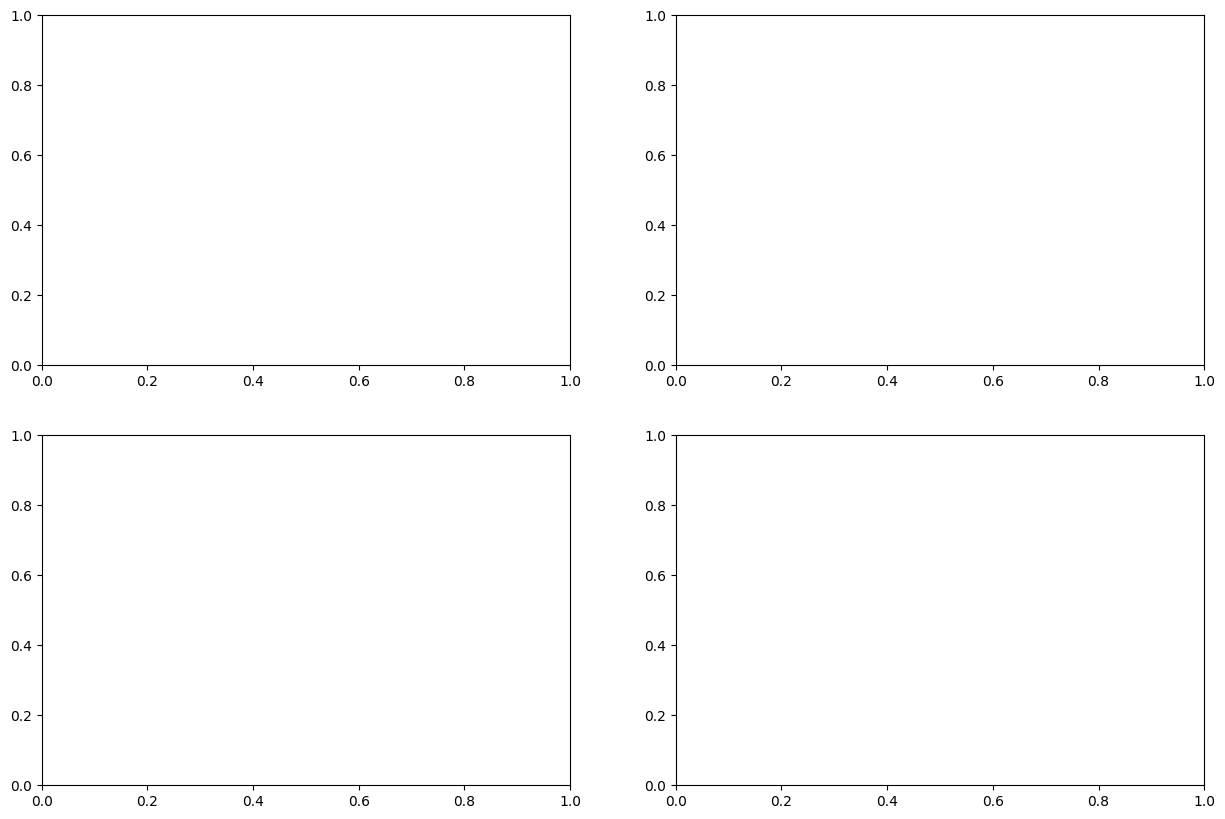

In [9]:
# Distribution of clicks and history length
if 'df' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Click distribution
    df['click'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0,0], colors=['lightcoral', 'lightgreen'])
    axes[0,0].set_title('Click Distribution', fontsize=14)
    axes[0,0].set_ylabel('')
    
    # History length distribution
    sns.histplot(df['hist_length'], bins=30, ax=axes[0,1], color='purple')
    axes[0,1].set_title('Distribution of User History Length', fontsize=14)
    axes[0,1].set_xlabel('History Length')
    
    # CTR by history length (box plot)
    df_sample = df.sample(min(10000, len(df)))  # Sample for performance
    sns.boxplot(x='click', y='hist_length', data=df_sample, ax=axes[1,0])
    axes[1,0].set_title('History Length vs Click', fontsize=14)
    
    # Scatter plot of history length vs CTR (aggregated)
    hist_ctr = df.groupby('hist_length')['click'].agg(['mean', 'count']).reset_index()
    hist_ctr = hist_ctr[hist_ctr['count'] > 10]  # Filter low count
    axes[1,1].scatter(hist_ctr['hist_length'], hist_ctr['mean'], s=hist_ctr['count']/100, alpha=0.6, color='orange')
    axes[1,1].set_title('CTR vs History Length (bubble size = count)', fontsize=14)
    axes[1,1].set_xlabel('History Length')
    axes[1,1].set_ylabel('CTR')
    
    plt.tight_layout()
    plt.show()

In [10]:
# Interactive Plotly visualization
if 'df' in locals():
    # CTR by category with interactive bar chart
    ctr_cat_df = ctr_by_cat.reset_index()
    ctr_cat_df.columns = ['Category', 'CTR']
    
    fig = px.bar(ctr_cat_df.head(20), x='Category', y='CTR', 
                 title='Interactive CTR by Category (Top 20)',
                 color='CTR', color_continuous_scale='Blues')
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()
    
    # 3D scatter plot of user behavior
    sample_df = df.sample(min(5000, len(df)))
    fig_3d = px.scatter_3d(sample_df, x='hist_length', y='category', z='click',
                          color='click', title='3D View: History Length, Category, and Click',
                          opacity=0.7)
    fig_3d.show()

NameError: name 'ctr_by_cat' is not defined

In [11]:
# Advanced Analysis: Category Transition Analysis
if 'df' in locals():
    # Create transition matrix (simplified)
    from collections import defaultdict
    
    transitions = defaultdict(lambda: defaultdict(int))
    
    for _, row in df.iterrows():
        if pd.notnull(row['hist_categories']):
            hist_cats = str(row['hist_categories']).split('')
            current_cat = str(row['category'])
            for h_cat in hist_cats[-5:]:  # Last 5 historical categories
                if h_cat:
                    transitions[h_cat][current_cat] += 1
    
    # Convert to DataFrame
    trans_df = pd.DataFrame(transitions).fillna(0)
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(trans_df.head(20).T.head(20), cmap='YlOrRd', annot=False, fmt='.0f')
    plt.title('Category Transition Heatmap (Top 20 Categories)', fontsize=16)
    plt.xlabel('Historical Category')
    plt.ylabel('Current Category')
    plt.tight_layout()
    plt.show()

KeyError: 'hist_categories'

In [ ]:
# Radar Chart for Top Categories CTR
if 'df' in locals():
    import plotly.graph_objects as go
    
    top_cats = ctr_by_cat.head(10)
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatterpolar(
        r=top_cats.values,
        theta=top_cats.index,
        fill='toself',
        name='CTR by Category'
    ))
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, max(top_cats.values) * 1.1]
            )),
        showlegend=False,
        title="Radar Chart: CTR by Top 10 Categories"
    )
    
    fig.show()
    
    # Summary
    print("### Summary of Click-Through Rate Analysis")
    print(f"- Overall CTR: {overall_ctr:.4f}")
    print(f"- Number of users: {df['user'].nunique()}")
    print(f"- Number of items: {df['movie_id'].nunique()}")
    print(f"- Number of categories: {df['category'].nunique()}")
    print(f"- Average history length: {df['hist_length'].mean():.2f}")
    print(f"- Max history length: {df['hist_length'].max()}")